# AML - Butterflies

This project aims to develop a 3 differente models of Neural Networks (MLP, CNN and ResNets), with different Loss functions

## Files Setup

In [1]:
from google.colab import drive
from pathlib import Path
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
try:
    path = Path('/content/drive/MyDrive/Universidade/Mestrado/2 Semestre/Aprendizagem Computacional Avançada/TP1-Students/aca-butterflies')
   
    if not path.exists():
        raise FileNotFoundError(f"The specified path does not exist: {path}")

except FileNotFoundError:
    path = Path('/content/drive/MyDrive/AdvancedMachineLearning/aca-butterflies')

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.utils.data as data
import torchvision.transforms as transforms

import warnings
warnings.filterwarnings("ignore")

In [9]:
BATCH_SIZE = 32
IMAGE_SIZE = 64

### Dataset manipulation class

In [10]:
class ButterflyDataset(data.Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.img_labels = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.img_labels['label'].unique())
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_name = self.img_labels.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label_name = self.img_labels.iloc[idx]['label']
        label_idx = self.class_to_idx[label_name]
        label = torch.tensor(label_idx, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

First, we read the dataset, preprocess the images and encapsulate them into dataloader form.

In [11]:
# load the data
img_dir = os.path.join(path, 'train')
df = pd.read_csv(os.path.join(path, 'train.csv'))

# preprocessing
data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

# encapsulate data into dataloader form
dataset = ButterflyDataset(df=df, img_dir=img_dir, transform=data_transform)
dataloader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [12]:
print(f"Number of samples: {len(dataset)}")
print(f"Number of classes: {len(dataset.classes)}")

Number of samples: 5199
Number of classes: 75


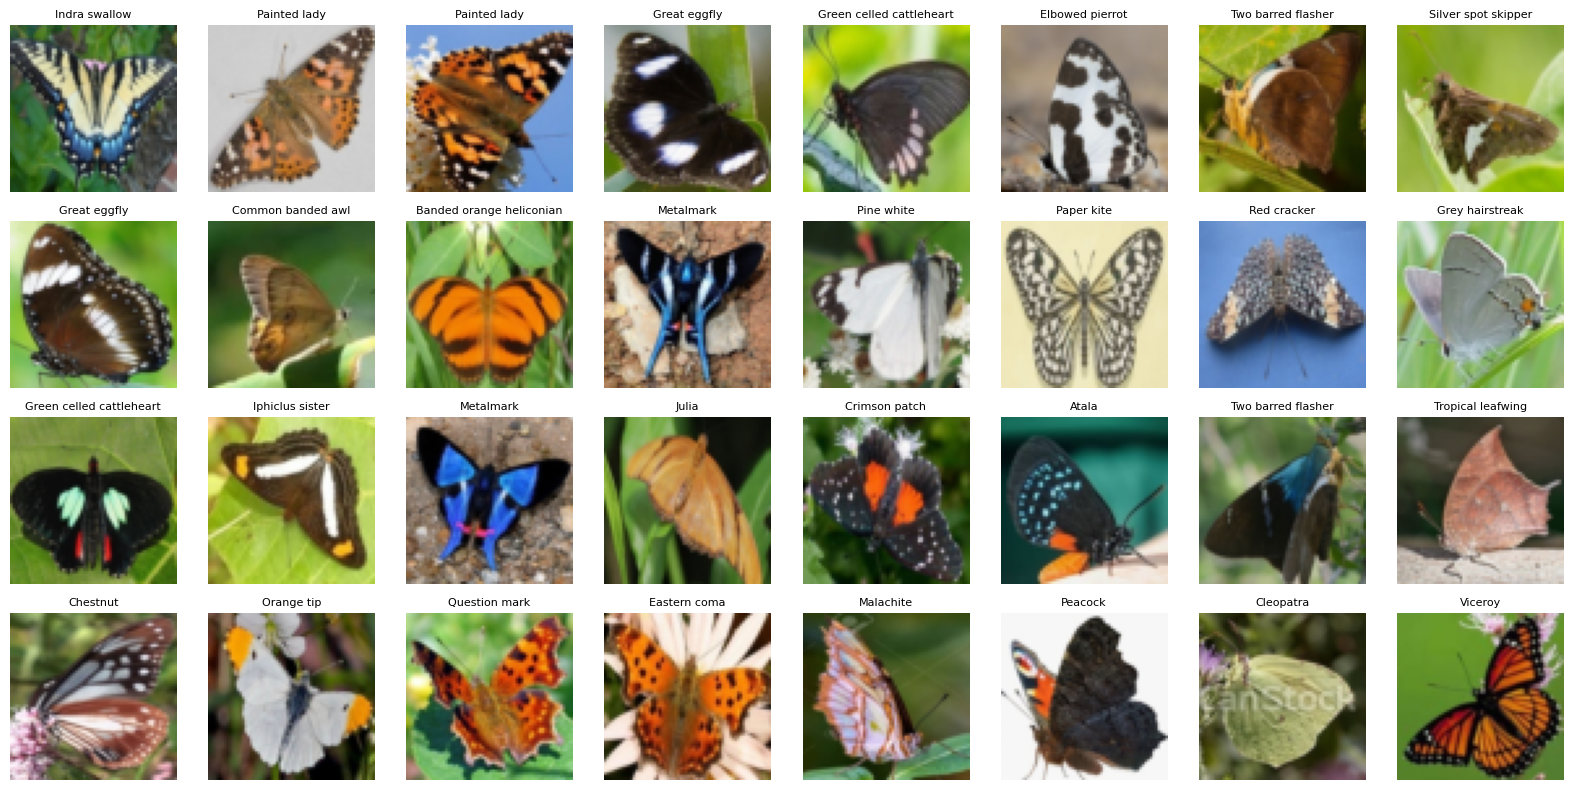

In [13]:
images, labels = next(iter(dataloader))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i in range(len(images)):
    img = images[i].permute(1, 2, 0).numpy()
    label_idx = labels[i].item()
    label_name = dataset.classes[label_idx]

    axes[i].imshow(img)
    axes[i].set_title(label_name.capitalize(), fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Dataset analysis

### Class distribution

Class distribution:
label
CLOUDED SULPHUR       105
GREAT JAY             105
BLACK HAIRSTREAK      105
INDRA SWALLOW         105
VICEROY               105
                     ... 
TWO BARRED FLASHER    105
WOOD SATYR            105
CHESTNUT              105
BLUE MORPHO           105
DANAID EGGFLY         105
Name: count, Length: 75, dtype: int64


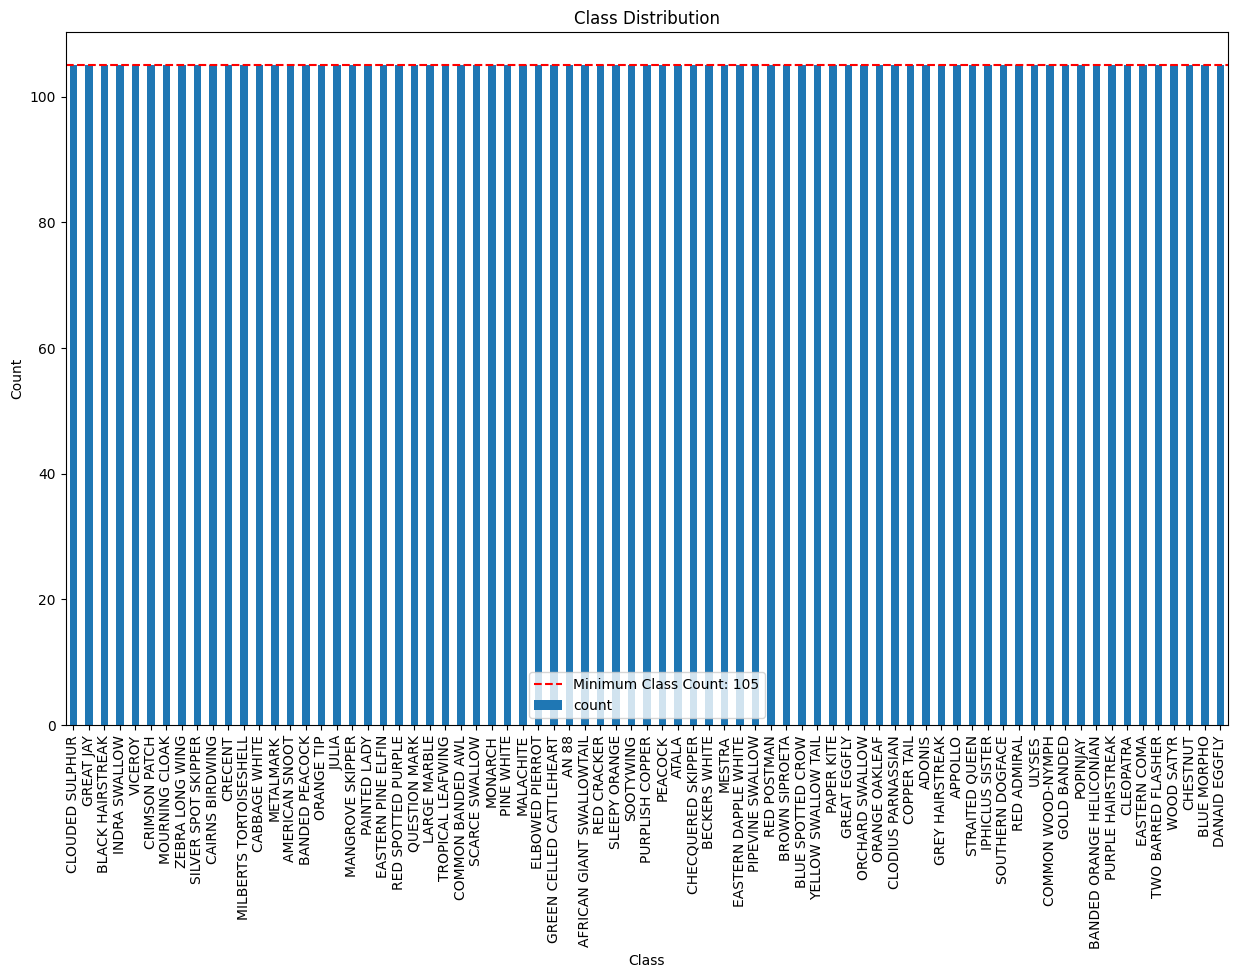

In [21]:
# Compute class distribution
import matplotlib.pyplot as plt

class_counts = df['label'].value_counts()
print("Class distribution:")
print(class_counts)

# Plot class distribution
plt.figure(figsize=(15, 9))
class_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.axhline(y=class_counts.min(), color='red', linestyle='--', label=f'Minimum Class Count: {class_counts.min()}')
plt.xticks(rotation=90)
plt.legend()
plt.show()

At first analysis the dataset was deeply unbalanced, so we must to explore different techniques to deal with this issue

## Oversampling

In [ ]:
import random

random.seed(42)

majority_class = class_counts.idxmax()
minority_classes = class_counts[class_counts < class_counts.max()].index

print(f"Majority class: {majority_class} with {class_counts.max()} samples")
print(f"Minority classes length: {len(minority_classes)}")


for minority_class in minority_classes:
    minority_count = class_counts[minority_class]
    majority_count = class_counts[majority_class]
    samples_to_add = majority_count - minority_count

    print(f"Class '{minority_class}' has {minority_count} samples. Adding {samples_to_add} samples to match the majority class.")

    # Get all images of the minority class
    minority_images = df[df['label'] == minority_class]['filename'].tolist()

    # Randomly sample images from the minority class to create new samples
    for _ in range(samples_to_add):
        img_name = random.choice(minority_images)
        img_path = os.path.join(img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        # Apply random transformations
        transform = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor()
        ])

        transformed_image = transform(image)

        # Save the transformed image with a new name
        new_img_name = f"{minority_class}_aug_{_}.jpg"
        new_img_path = os.path.join(img_dir, new_img_name)
        transformed_image_pil = transforms.ToPILImage()(transformed_image)
        transformed_image_pil.save(new_img_path)

        # Add the new sample to the dataframe
        new_row = pd.DataFrame([{'filename': new_img_name, 'label': minority_class}])
        df = pd.concat([df, new_row], ignore_index=True)

# Verify the new class distribution
new_class_counts = df['label'].value_counts()
print("New class distribution after oversampling:")
print(new_class_counts)

Majority class: MOURNING CLOAK with 105 samples
Minority classes length: 74
Class 'SLEEPY ORANGE' has 85 samples. Adding 20 samples to match the majority class.
Image_5041.jpg
Image_690.jpg
Image_182.jpg
SLEEPY ORANGE_aug_9.jpg
Image_2381.jpg
Image_2140.jpg
Image_1840.jpg
Image_945.jpg
SLEEPY ORANGE_aug_9.jpg
Image_670.jpg
SLEEPY ORANGE_aug_1.jpg
SLEEPY ORANGE_aug_9.jpg
Image_3975.jpg
Image_648.jpg
Image_4500.jpg
Image_3079.jpg
Image_232.jpg
Image_182.jpg
Image_648.jpg
Image_1799.jpg
Class 'ATALA' has 80 samples. Adding 25 samples to match the majority class.
Image_2211.jpg
Image_4365.jpg
Image_4994.jpg
Image_122.jpg
Image_4601.jpg
Image_1610.jpg
ATALA_aug_11.jpg
ATALA_aug_3.jpg
ATALA_aug_9.jpg
Image_4562.jpg
Image_3688.jpg
Image_1854.jpg
Image_4023.jpg
Image_4824.jpg
Image_2660.jpg
ATALA_aug_23.jpg
Image_49.jpg
ATALA_aug_17.jpg
ATALA_aug_23.jpg
Image_1340.jpg
ATALA_aug_9.jpg
Image_3748.jpg
Image_3102.jpg
Image_2660.jpg
Image_1290.jpg
Class 'BROWN SIPROETA' has 79 samples. Adding 26 sa

KeyboardInterrupt: 

New shape of the dataset after oversampling: (7875, 2)


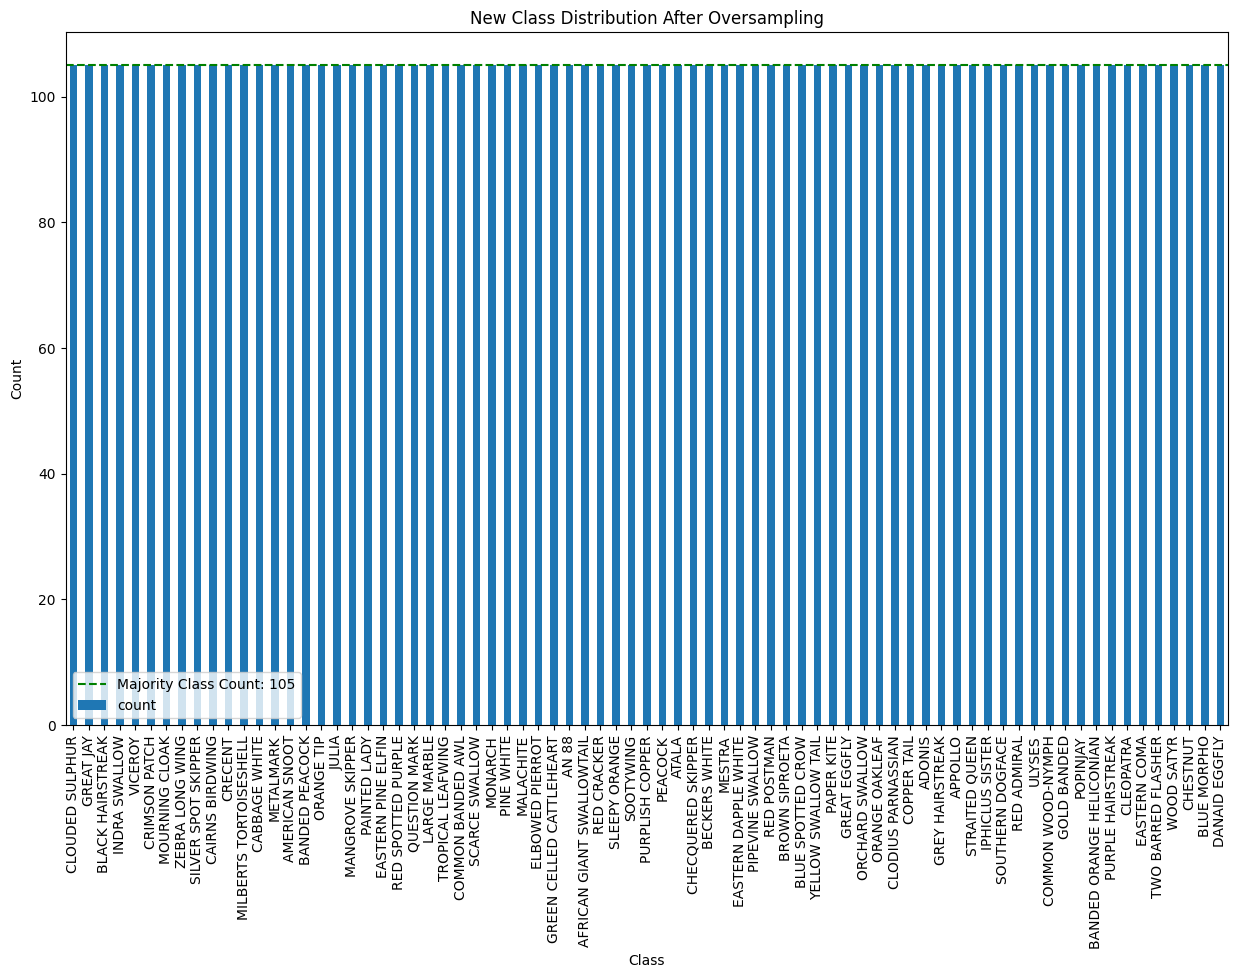

In [59]:
print("New shape of the dataset after oversampling:", df.shape)

plt.figure(figsize=(15, 9))
new_class_counts.plot(kind='bar')
plt.title('New Class Distribution After Oversampling')
plt.xlabel('Class')
plt.ylabel('Count')
plt.axhline(y=class_counts.max(), color='green', linestyle='--', label=f'Majority Class Count: {class_counts.max()}')
plt.xticks(rotation=90)
plt.legend()
plt.show()


In [16]:
df.head()
df.to_csv(os.path.join(path, 'train_oversampled.csv'), index=False)

## Class Weighting

### Compute the class weights for each class

In [ ]:
df_original = pd.read_csv(os.path.join(path, 'train.csv'))

# Compute class distribution for the original dataset
class_counts = df_original['label'].value_counts()
print("Class distribution:")
print(class_counts)

# Compute the weight for each class
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
print("\nClass weights:")
print(class_weights)

# Convert to tensors
class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32)
print("\nClass weights tensor:")
print(class_weights_tensor)

loss = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

dataset = ButterflyDataset(df=df_original, img_dir=img_dir, transform=data_transform)
dataloader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

Class distribution:
label
MOURNING CLOAK    105
SLEEPY ORANGE      85
ATALA              80
BROWN SIPROETA     79
ORANGE TIP         77
                 ... 
AMERICAN SNOOT     59
CRIMSON PATCH      58
MALACHITE          58
GOLD BANDED        58
WOOD SATYR         57
Name: count, Length: 75, dtype: int64

Class weights:
label
MOURNING CLOAK    0.653473
SLEEPY ORANGE     0.807232
ATALA             0.857684
BROWN SIPROETA    0.868540
ORANGE TIP        0.891100
                    ...   
AMERICAN SNOOT    1.162961
CRIMSON PATCH     1.183012
MALACHITE         1.183012
GOLD BANDED       1.183012
WOOD SATYR        1.203767
Name: count, Length: 75, dtype: float64

Class weights tensor:
tensor([0.6535, 0.8072, 0.8577, 0.8685, 0.8911, 0.8911, 0.8911, 0.8911, 0.8911,
        0.8911, 0.9028, 0.9028, 0.9028, 0.9149, 0.9149, 0.9149, 0.9272, 0.9272,
        0.9272, 0.9272, 0.9272, 0.9530, 0.9530, 0.9530, 0.9530, 0.9530, 0.9530,
        0.9664, 0.9802, 0.9802, 0.9802, 0.9802, 0.9802, 0.9802, 0.9802, 

### Multi-Layer Perceptron

In [ ]:
import torch.nn as nn
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten the input
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x